# Exercises week 35

**FYS-STK3155/4155 — Applied Data Analysis and Machine Learning**

**August 24–30, 2026. Deadline: Friday August 28 at midnight.**

Reading for this set: the book, Chapter 3 (in particular Sections 3.1–3.7 from
week 34 and Sections 3.7–3.10 and 3.13 from this week), and the week 35 slides
(`week35slides.pdf`, `week35tuesday.pdf`). The Tuesday session and its notebook
(`week35tuesday.ipynb`) walk through most of the code you need here. For
exercise 1 the book by Faisal, Ong and Deisenroth, *Mathematics for Machine
Learning*, chapter 5 (sections 5.3–5.5) at https://mml-book.github.io/ is very
useful.

## Exercise 1: Analytical exercises

In this exercise we derive the expressions for various derivatives of products of
vectors and matrices. Such derivatives are central to the optimization of various
cost functions. Although we will often use automatic differentiation in actual
calculations, having the analytical expressions is extremely helpful in case we
have simpler derivatives, as well as when we analyze various properties (like
second derivatives) of the chosen cost functions. Vectors are always written as
boldfaced lower-case letters and matrices as upper-case boldfaced letters.
Note that throughout we use the numerator (Jacobian) layout, in which the derivative of a
*scalar* with respect to a vector is a **row** vector — consistent with the example
$\partial(\boldsymbol{A}\boldsymbol{x})/\partial\boldsymbol{x}=\boldsymbol{A}$ in the hint below and with Faisal et al.; if you prefer the
column-gradient convention you will obtain the equivalent transposed results, e.g.
$(\boldsymbol{A}+\boldsymbol{A}^T)\boldsymbol{a}$ instead of $\boldsymbol{a}^T(\boldsymbol{A}+\boldsymbol{A}^T)$.

Show that

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{a}^T,
$$

and

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right),
$$

and

$$
\frac{\partial \left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}} = -2\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\boldsymbol{A},
$$

and finally find the second derivative of this function with respect to the vector
$\boldsymbol{s}$.

If we replace the vector $\boldsymbol{s}$ with the unknown parameters
$\boldsymbol{\theta}$ used to define the ordinary least squares method, we end up
with the equations that determine these parameters. The matrix $\boldsymbol{A}$ is
then the design matrix $\boldsymbol{X}$, and $\boldsymbol{x}$ has to be replaced
with the outputs $\boldsymbol{y}$. The second derivative of the mean squared error
is then proportional to the Hessian matrix
$\boldsymbol{H}=\boldsymbol{X}^T\boldsymbol{X}$.

**Hint:** it is always useful to write out with summation indices the various
quantities; take a look at the examples in the week 35 slides. As an example,
consider the function

$$
f(\boldsymbol{x}) = \boldsymbol{A}\boldsymbol{x},
$$

which reads for a specific component $f_i$ (defining $\boldsymbol{A}$ to be an
$n\times n$ matrix and $\boldsymbol{x}$ a vector of length $n$)

$$
f_i = \sum_{j=0}^{n-1} a_{ij} x_j,
$$

which leads to

$$
\frac{\partial f_i}{\partial x_j} = a_{ij},
$$

and written out in terms of the vector $\boldsymbol{x}$ we have

$$
\frac{\partial f(\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{A}.
$$

## Exercise 2: Making your own data and exploring scikit-learn

We will generate our own dataset for a function $y(x)$ where $x\in[0,1]$ and
defined by random numbers computed with the uniform distribution. The function $y$
is a quadratic polynomial in $x$ with added stochastic noise according to the
normal distribution $\mathcal{N}(0,1)$. The following simple Python instructions
define our $x$ and $y$ values (with 100 data points).

In [14]:
import numpy as np

rng = np.random.default_rng(2026)
x = rng.random((100, 1))
y = 2.0 + 5.0 * x * x + 0.1 * rng.standard_normal((100, 1))

1. Write your own code (following the examples in the book, Chapter 3, and the
   week 34–35 slides) for computing the parametrization of the data set, fitting a
   second-order polynomial. That is, set up the design matrix
   $\boldsymbol{X}$ with columns $1, x, x^2$ and find the optimal parameters
   $\boldsymbol{\theta}$ from the normal equations (or, better, through the SVD —
   see the week 34 discussion of why we never invert
   $\boldsymbol{X}^T\boldsymbol{X}$).

2. Use thereafter **scikit-learn** (see the examples in the week 35 slides and the
   Tuesday notebook) and compare with your own code. Note that scikit-learn does
   not, by default, include the intercept in the design matrix. See the
   discussions on scaling your data in the week 35 slides (and Section 3.13 of the
   book). This type of problem appears in particular if we fit a polynomial with
   an intercept.

3. Using scikit-learn, compute also the mean squared error, a risk metric
   corresponding to the expected value of the squared (quadratic) error

$$
MSE(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}\left(y_i-\tilde{y}_i\right)^2,
$$

   and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
   $i$-th sample and $y_i$ is the corresponding true value, then the $R^2$ score is

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
$$

   where the mean value of $\boldsymbol{y}$ is

$$
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1} y_i.
$$

   You can use the functionality included in scikit-learn, or your own functions
   from the Tuesday notebook. Discuss the meaning of these results. Try also to
   vary the coefficient in front of the added stochastic noise term and discuss
   the quality of the fits.

(100, 3) (3,) (3, 3)
Estimated coefficients (theta) using OLS: [2. 0. 5.]
Estimated coefficients (theta) using scikit-learn: [ 2.00000000e+00 -2.66453526e-15  5.00000000e+00]


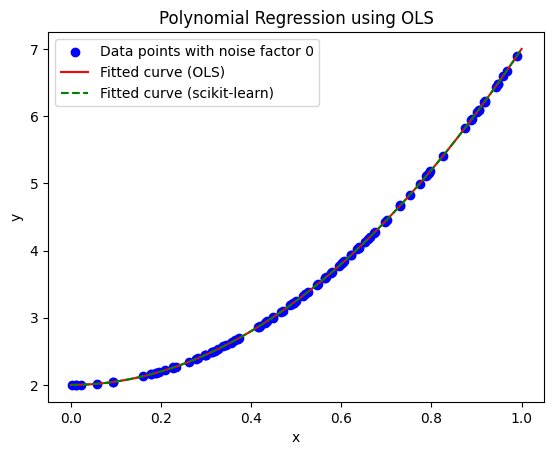

OLS - MSE: 0.000, R²: 1.000
scikit-learn - MSE: 0.000, R²: 1.000
(100, 3) (3,) (3, 3)
Estimated coefficients (theta) using OLS: [ 2.02088249 -0.09371634  5.06840849]
Estimated coefficients (theta) using scikit-learn: [ 2.02088249 -0.09371634  5.06840849]


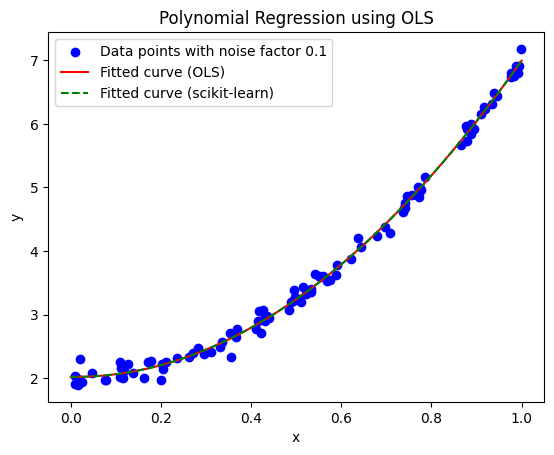

OLS - MSE: 0.009, R²: 0.996
scikit-learn - MSE: 0.009, R²: 0.996
(100, 3) (3,) (3, 3)
Estimated coefficients (theta) using OLS: [ 2.16445281 -0.10569766  4.77671847]
Estimated coefficients (theta) using scikit-learn: [ 2.16445281 -0.10569766  4.77671847]


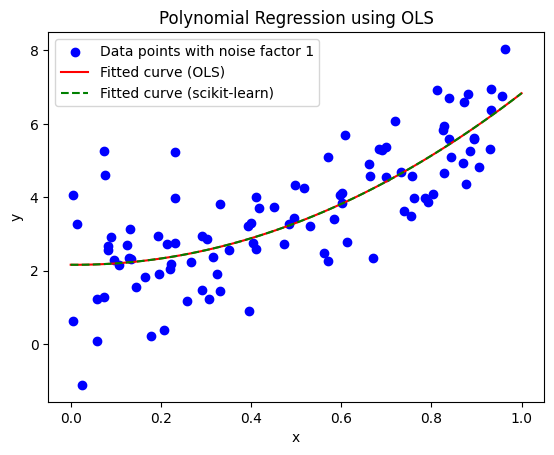

OLS - MSE: 1.209, R²: 0.607
scikit-learn - MSE: 1.209, R²: 0.607
(100, 3) (3,) (3, 3)
Estimated coefficients (theta) using OLS: [ 2.90396347 -0.97082538  7.41415698]
Estimated coefficients (theta) using scikit-learn: [ 2.90396347 -0.97082538  7.41415698]


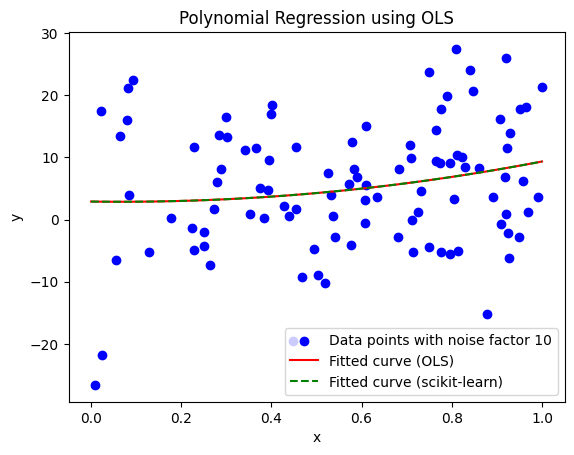

OLS - MSE: 102.627, R²: 0.037
scikit-learn - MSE: 102.627, R²: 0.037


In [21]:
# Your code for exercise 2 here
rng = np.random.default_rng(2026)

import numpy as np
import matplotlib.pyplot as plt


def mse(y, y_tilde):
    return np.mean((y - y_tilde) ** 2)

def r2(y, y_tilde):
    mean_y = np.mean(y)
    
    return 1 - np.sum((y - y_tilde)**2) / np.sum((y - mean_y)**2)

def exercise2(noise_level=0.1, deg=2):
    x = rng.random((100, 1))
    y = 2.0 + 5.0 * x * x + noise_level * rng.standard_normal((100, 1))

    # feature matrix of shape (100, deg)
    X_matrix = np.column_stack([x**i for i in range(deg + 1)])

    X_transposed = np.transpose(X_matrix)

    '''# SVD
    U, S, Vh = np.linalg.svd(X_matrix)

    theta_OLS = np.sum(U.transpose() * y / S * Vh.transpose(), axis=1)'''
    # Giving the above code and the equation 3.11 [Morten Hjorth-Jensen, 2026]
    # $\theta_{OLS} = \sum_{i=0}^{r-1}\left(\frac{\bold{u_i}^T\bold{y}}{\bold{\sigma_i}}\bold{v_i}\right)$
    # to [GPT-5.6 Luna]
    # corrected the code after one feedback on a missmatch of the dimensions of S, 
    # the working principle was understood and verified by printing shape and numerical values of the decomposed matrices U, S, Vh and the intermediate result of the summation.
    # The comparison with scikit-learn's LinearRegression also verifies the correct result.

    # SVD
    U, S, Vh = np.linalg.svd(X_matrix, full_matrices=False)
    theta_OLS = Vh.T @ ((U.T @ y) / S[:, None])

    print(U.shape, S.shape, Vh.shape)
    '''print(U)
    print(S)
    print(((U.T @ y) / S[:, None]))
    print(Vh)'''

    print("Estimated coefficients (theta) using OLS:", theta_OLS.flatten())

    # regression using scikit-learn (Copilot generated)
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, r2_score
    model = LinearRegression(fit_intercept=False)
    model.fit(X_matrix, y)
    print("Estimated coefficients (theta) using scikit-learn:", model.coef_.flatten())

    # plot the data and the fitted curve
    plt.scatter(x, y, color='blue', label=f'Data points with noise factor {noise_level}')
    x_fit = np.linspace(0, 1, 100).reshape(-1, 1)
    X_fit = np.column_stack([x_fit**i for i in range(deg + 1)])

    y_fit = X_fit.dot(theta_OLS)
    plt.plot(x_fit, y_fit, color='red', label='Fitted curve (OLS)')

    coef_sklearn = model.coef_.flatten()
    y_fit_sklearn = X_fit.dot(coef_sklearn)
    plt.plot(x_fit, y_fit_sklearn, color='green', linestyle='--', label='Fitted curve (scikit-learn)')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Polynomial Regression using OLS')
    plt.legend()
    plt.show()


    # print mean squared error and R-squared for both methods
    y_tilde_OLS = X_matrix.dot(theta_OLS)
    mse_OLS = mse(y, y_tilde_OLS)
    r2_OLS = r2(y, y_tilde_OLS)
    '''
    y_tilde_sklearn = X_matrix.dot(coef_sklearn)
    mse_sklearn = mean_squared_error_own(y, y_tilde_sklearn)
    r2_sklearn = r_squared(y, y_tilde_sklearn)'''
    y_tilde_sklearn = X_matrix.dot(coef_sklearn)
    mse_sklearn = mean_squared_error(y, y_tilde_sklearn)
    r2_sklearn = r2_score(y, y_tilde_sklearn)


    print(f"OLS - MSE: {mse_OLS:.3f}, R²: {r2_OLS:.3f}")
    print(f"scikit-learn - MSE: {mse_sklearn:.3f}, R²: {r2_sklearn:.3f}")


exercise2(noise_level=0)
exercise2()
exercise2(noise_level=1)
exercise2(noise_level=10)

>## Discussion
>- using scikit-learn or the SVD module of numpy results in the same $\bold{\hat{\theta}}_\text{OLS}$ in all three cases
>- both methods therefor also do not differ in the resulting MSE- and $R^2$-value
>
>| Noise-Level | MSE | $R^2$ | Comment|
>| -------- | ------- | -------- | -------- |
>|0 |  0.000| 1.000 | perfect fit|
>|0.1 | 0.009| 0.996| increase in noise slightly increases MSE, the $R^2$ is still almost 1, still a well description of the data by the model|
>|1 | 1.209 | 0.607 | the noise on the data becomes noticable in the fit: the MSE increases above the noise-level and the $R^2$ decreases to 60% |
>|10 | 102.627 | 0.037 | $R^2$ almost zero, the fit represents only the mean of the data|



## Exercise 3: Split data in test and training data

In this exercise we want you to compute the MSE for the training data and the test
data as a function of the complexity of a polynomial, that is the degree of a given
polynomial.

The aim is to reproduce Figure 2.11 of Hastie et al., *The Elements of Statistical
Learning*. Feel free to read the discussions leading to that figure.

Our data is defined by $x\in[-3,3]$ with a total of, for example, $n=100$ data
points. You should try to vary the number of data points $n$ in your analysis.

In [ ]:
n = 100
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)

where $y$ is the function we want to fit with a given polynomial.

1. Write a first code which sets up a design matrix $\boldsymbol{X}$ defined by a
   fifth-order polynomial and split your data set into training and test data
   (`sklearn.model_selection.train_test_split` is fine).

2. Write thereafter (using either scikit-learn or your matrix inversion/SVD code)
   an ordinary least squares fit and compute the mean squared error for the
   training data and the test data. These calculations should apply to a model
   given by a fifth-order polynomial. If you compare your own code with
   scikit-learn, note that the latter does not include the intercept by default —
   see the discussions on scaling in the week 35 slides.

3. Add now a model which allows you to make polynomials up to degree $15$. Perform
   a standard OLS fit of the training data and compute the MSE for the training
   and test data and plot both as functions of the polynomial degree. Compare what
   you see with Figure 2.11 of Hastie et al. Comment on your results. For which
   polynomial degree do you find the optimal (smallest) test MSE?

Degree: 5, Train MSE: 0.0206, Test MSE: 0.0177
Degree: 6, Train MSE: 0.0164, Test MSE: 0.0119
Degree: 7, Train MSE: 0.0120, Test MSE: 0.0119
Degree: 8, Train MSE: 0.0087, Test MSE: 0.0074
Degree: 9, Train MSE: 0.0086, Test MSE: 0.0075
Degree: 10, Train MSE: 0.0074, Test MSE: 0.0104
Degree: 11, Train MSE: 0.0074, Test MSE: 0.0130
Degree: 12, Train MSE: 0.0074, Test MSE: 0.0115
Degree: 13, Train MSE: 0.0072, Test MSE: 0.0091
Degree: 14, Train MSE: 0.0072, Test MSE: 0.0101
Degree: 15, Train MSE: 0.0072, Test MSE: 0.0087
Degree: 16, Train MSE: 0.0072, Test MSE: 0.0085


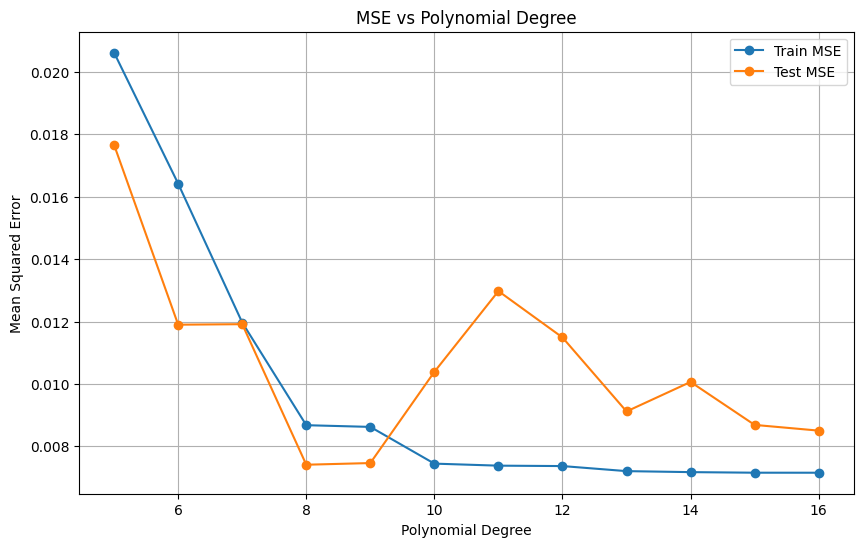

In [22]:
# Your code for exercise 3 here
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 100
deg = 5

# Make data set.
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x-2)**2)+ np.random.normal(0, 0.1, x.shape)

def ordinary_least_squares(X, y):

    # SVD and get theta_OLS from the pesudo-inverse
    U, S, Vh = np.linalg.svd(X, full_matrices=False)
    theta_OLS = Vh.T @ ((U.T @ y) / S[:, None])

    return theta_OLS

degrees = np.arange(5, 17)
mse_train_arr = []
mse_test_arr = []

for deg in degrees:
    # feature matrix of shape (n, deg)
    X_matrix = np.column_stack([x**i for i in range(deg + 1)])
    X_train, X_test, y_train, y_test = train_test_split(X_matrix, y, test_size=0.2, random_state=42)

    theta_OLS = ordinary_least_squares(X_train, y_train)

    # calc MSE for train and test sets
    mse_train = mse(y_train, X_train.dot(theta_OLS))
    mse_test = mse(y_test, X_test.dot(theta_OLS))

    mse_train_arr.append(mse_train)
    mse_test_arr.append(mse_test)

    print(f"Degree: {deg}, Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")

# plot MSE vs degree
plt.figure(figsize=(10, 6))
plt.plot(degrees, mse_train_arr, marker='o', label='Train MSE')
plt.plot(degrees, mse_test_arr, marker='o', label='Test MSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs Polynomial Degree')
plt.legend()
plt.grid()
plt.show()


## Discussion
> - Figure 2.11 of Hastie et al. shows a monotonous fall of the training data and a clear U shape of the test sample data
> - the plot above also monotonougly decreases in the training set but can not reproduce the clear global minimum of the test set data
> - the difference in both pictures will most likely result due to statistical fluctutations
> - however, the picture qualitively shows the inital decrease in the test set MSE followed by another increase do to overfitting effects
> - the minimal MSE in the test set is 0.0074 with a degree 8 polynomial

## Exercise 4 (optional): a first taste of Ridge

This voluntary exercise connects directly to Monday's lecture and to Case 4 of the
Tuesday notebook; it is also a useful warm-up for Project 1.

Keep the data set and the degree-15 design matrix from exercise 3, standardise the
feature columns (training statistics only!), and replace OLS by Ridge regression,

$$
\hat{\boldsymbol{\theta}}_{\mathrm{Ridge}} = \left(\boldsymbol{X}^T\boldsymbol{X}+\lambda\boldsymbol{I}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}.
$$

1. Plot the training and test MSE as functions of $\lambda$ on a logarithmic grid,
   say $\lambda\in[10^{-8},10^{4}]$. Do you find the U-shape discussed in the
   lecture?

2. Compare your best test MSE with the best value found in exercise 3 by varying
   the polynomial degree. Two dials, one phenomenon — which gives the finer
   control?

3. Check explicitly that your training MSE is monotonically increasing in
   $\lambda$, and explain in one sentence why it must be.

In [ ]:
# Your code for exercise 4 here
